## Figure 1 of manuscript showing shapshot of SIC, SSS, and SST for ice bridge

In [1]:
## import required packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
from pyproj import Proj, Transformer
import glob
import os
import string
from datetime import datetime

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:42433")
client

<Client: 'tcp://127.0.0.1:42433' processes=8 threads=32, memory=123.95 GiB>

### Make plot for main manuscript that shows Sept sea ice min, ice bridge, and one week before and after

First calculation sea ice minimum for Beaufort Sea box

In [3]:
# Set data directory and load all matching NetCDF files
data_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr"
sic_file_paths_2022 = sorted(glob.glob(os.path.join(data_dir, "*2022*.nc")))

data_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data/sss_rss_smap"
sss_file_paths_2022 = sorted(glob.glob(os.path.join(data_dir, "*2022*.nc")))

data_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data/sst_noaa_oisst"
sst_file_paths_2022 = sorted(glob.glob(os.path.join(data_dir, "*2022*.nc")))

Plot 2x4 plot

In [117]:
# select specific dates for fig 1
sic_file_paths = [[item for item in sic_file_paths_2022 if '20220923' in item][0],\
                  [item for item in sic_file_paths_2022 if '20221015' in item][0],\
                  [item for item in sic_file_paths_2022 if '20221022' in item][0],\
                  [item for item in sic_file_paths_2022 if '20221029' in item][0]]

In [118]:
# sss is reported in DOY not mon/day
dates = ['20220923', '20221015', '20221022', '20221029']
for date_str in dates:
    dt = datetime.strptime(date_str, '%Y%m%d')
    doy = dt.timetuple().tm_yday
    print(f"{date_str} -> DOY {doy}")

20220923 -> DOY 266
20221015 -> DOY 288
20221022 -> DOY 295
20221029 -> DOY 302


In [119]:
# The SMAP radiometer was put in safehold mode during Julian days 218 – 265 (06 AUG – 21
# SEP) in 2022. No L2C and 8-day L3 files are available during this time period. No monthly L3
# files are produced for AUG – SEP 2022
len(sss_file_paths_2022)

317

In [120]:
# select specific dates for fig 1
sss_file_paths = [[item for item in sss_file_paths_2022 if '2022_266' in item][0],\
                  [item for item in sss_file_paths_2022 if '2022_288' in item][0],\
                  [item for item in sss_file_paths_2022 if '2022_295' in item][0],\
                  [item for item in sss_file_paths_2022 if '2022_302' in item][0]]

In [121]:
tmp = xr.open_dataset(sss_file_paths[2])

In [122]:
tmp

<xarray.Dataset> Size: 153MB
Dimensions:                 (lon: 1440, lat: 720, time: 1,
                             uncertainty_components: 9, iceflag_components: 3)
Coordinates:
  * lon                     (lon) float32 6kB 0.125 0.375 0.625 ... 359.6 359.9
  * lat                     (lat) float32 3kB -89.88 -89.62 ... 89.62 89.88
  * time                    (time) datetime64[ns] 8B 2022-10-22T12:00:00
Dimensions without coordinates: uncertainty_components, iceflag_components
Data variables: (12/19)
    nobs                    (lat, lon) float64 8MB ...
    nobs_RF                 (lat, lon) float64 8MB ...
    nobs_40km               (lat, lon) float64 8MB ...
    sss_smap                (lat, lon) float32 4MB ...
    sss_smap_RF             (lat, lon) float32 4MB ...
    sss_smap_unc            (lat, lon) float32 4MB ...
    ...                      ...
    fland                   (lat, lon) float32 4MB ...
    gice_est                (lat, lon) float32 4MB ...
    surtep                  (lat, lon) float32 4MB ...
    winspd                  (lat, lon) float32 4MB ...
    sea_ice_zones           (lat, lon) int8 1MB ...
    anc_sea_ice_flag        (lat, lon, iceflag_components) int8 3MB ...
Attributes: (12/65)
    Conventions:                                            CF-1.7, ACDD-1.3
    title:                                                  SMAP ocean surfac...
    version:                                                V6.0 Validated Re...
    summary:                                                The dataset conta...
    acknowledgement:                                        Funded under Subc...
    processing_level:                                       L3
    ...                                                     ...
    Source_of_SMAP_SSS_retrievals:                          T. Meissner, F. W...
    Source_of_ancillary_SST:                                Canada Meteorolog...
    Source_of_ancillary_CCMP_wind_speed:                    Mears, C. et al.,...
    Source_of_ancillary_AMSR2_sea_ice_flag_and_correction:  Meissner, T. and ...
    Source_of_ancillary_land_mask:                          1 km land/water m...
    Source_of_ancillary_reference_SSS_from_HYCOM:           Hybrid Coordinate...

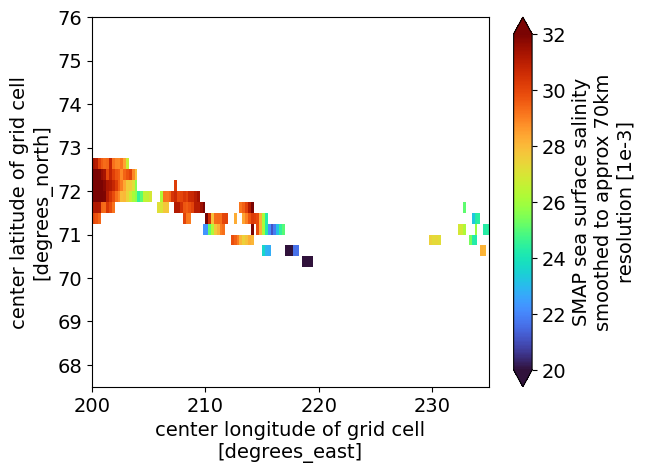

In [123]:
tmp.sss_smap.plot(vmin=20,vmax=32,cmap='turbo');
plt.xlim(200,235)
plt.ylim(67.5,76);

In [124]:
# select specific dates for fig 1
sst_file_paths = [[item for item in sst_file_paths_2022 if '20220923' in item][0],\
                  [item for item in sst_file_paths_2022 if '20221015' in item][0],\
                  [item for item in sst_file_paths_2022 if '20221022' in item][0],\
                  [item for item in sst_file_paths_2022 if '20221029' in item][0]]

In [125]:
tmp = xr.open_dataset(sst_file_paths[0])

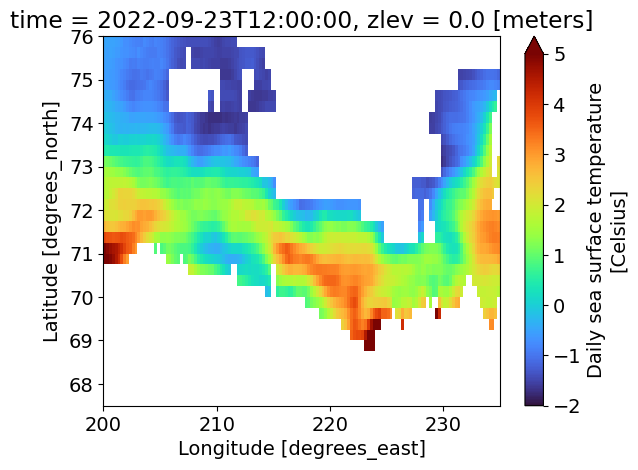

In [126]:
tmp.sst.where(tmp.ice.isnull()).plot(vmin=-2,vmax=5,cmap='turbo');
plt.xlim(200,235)
plt.ylim(67.5,76);

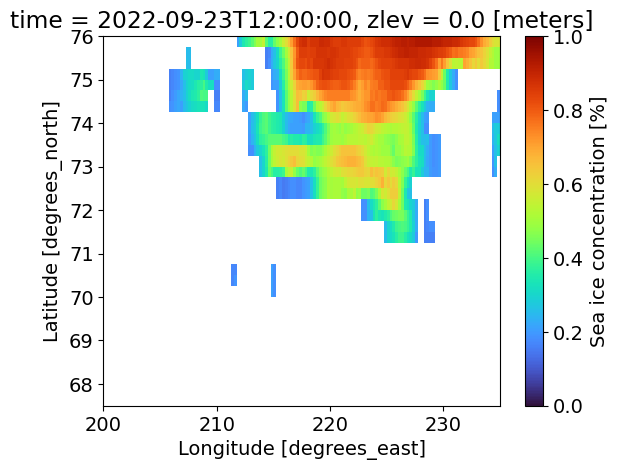

In [127]:
tmp.ice.plot(vmin=0,vmax=1,cmap='turbo');
plt.xlim(200,235)
plt.ylim(67.5,76);

In [128]:
def remap_colormap(cmap, nonlin_scale=np.sqrt, n=256):
    """
    Remap a colormap so that lower values are compressed (darker colors take up less space),
    and higher values (lighter colors) are stretched out.
    
    Parameters:
    - cmap: The original colormap (e.g., cmocean.cm.ice)
    - nonlin_scale: A function that maps [0,1] -> [0,1] nonlinearly (default: np.sqrt)
    - n: Number of color levels
    
    Returns:
    - A new colormap with redistributed colors.
    """
    # Generate linearly spaced values, then apply non-linear scaling
    orig_vals = np.linspace(0, 1, n)
    remapped_vals = nonlin_scale(orig_vals)

    # Normalize remapped values to stay in [0,1]
    remapped_vals = (remapped_vals - remapped_vals.min()) / (remapped_vals.max() - remapped_vals.min())

    # Map those values through the original colormap
    new_colors = cmap(remapped_vals)
    
    return LinearSegmentedColormap.from_list(f'remapped_{cmap.name}', new_colors, N=n)

In [129]:
from matplotlib.colors import LinearSegmentedColormap

# create a nonlinearly adjusted colormap from the cmocean ice colormap
custom_ice_cmap = remap_colormap(cmocean.cm.ice, nonlin_scale=np.sqrt)  # sqrt compresses low end

Version 1

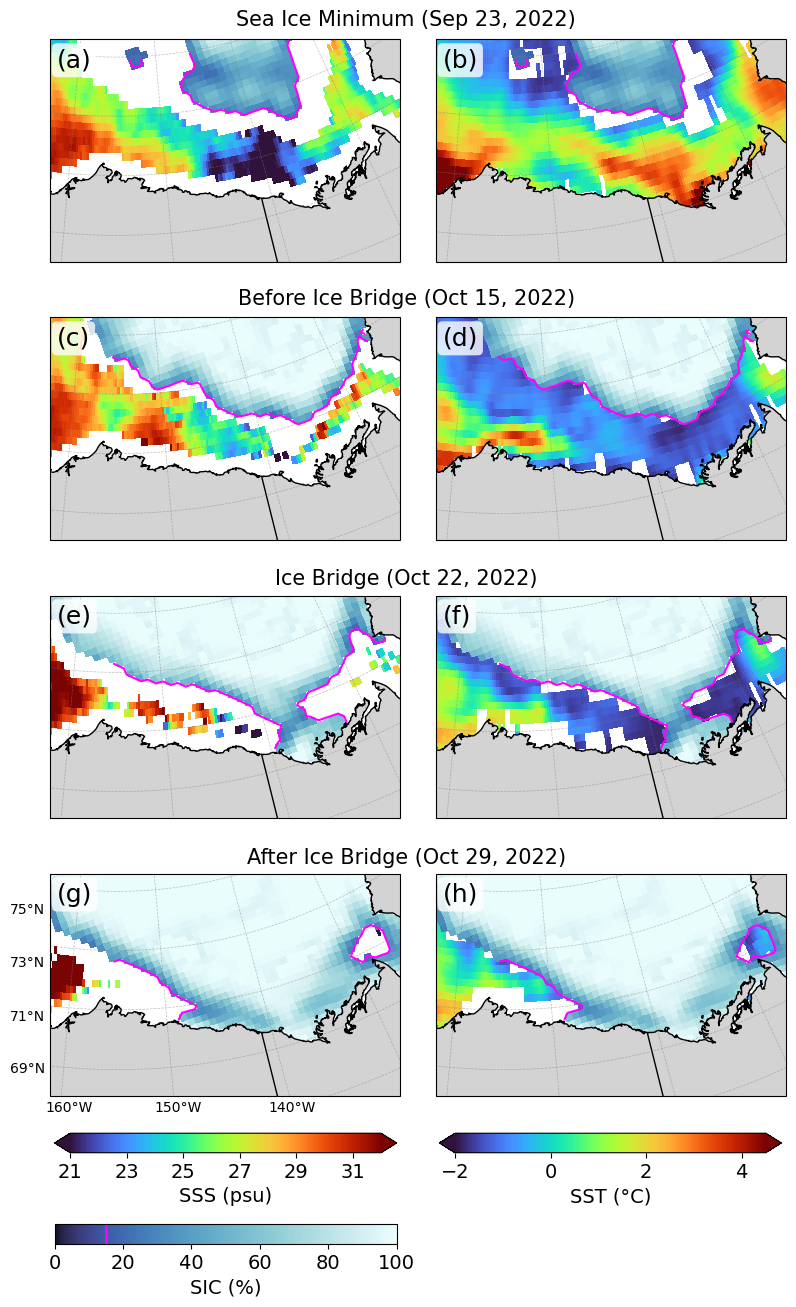

In [130]:
plt.rcParams['font.size'] = 14

# Define NSIDC stereographic projection
nsidc_proj = Proj(proj='stere', lat_0=90, lon_0=-45, lat_ts=70,
                  a=6378273, b=6356889.449, units='m')
transformer = Transformer.from_proj(nsidc_proj, "epsg:4326", always_xy=True)

# Create 4x2 plot
fig, axes = plt.subplots(4, 2, figsize=(9.5, 13),
                         subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)})
plt.subplots_adjust(wspace=0.1, hspace=0.2, right=0.9, top=0.93)
axes = axes.reshape(4, 2)

labels = list(string.ascii_lowercase)  # ['a', 'b', 'c', ...]
pcolormesh_handle = None  # for SIC colorbar

# To hold handles for SSS/SST colorbars
sss_im_list = []
sst_im_list = []

for i in range(len(sic_file_paths)):
    # Load SIC and convert
    sic_ds = xr.open_dataset(sic_file_paths[i])
    sic = sic_ds['cdr_seaice_conc'].squeeze()
    if sic.max() > 1.5:
        sic = sic / 100.0
    sic_masked = np.where(sic > 0.15, sic, np.nan)

    # Load SSS and SST
    sss = xr.open_dataset(sss_file_paths[i])['sss_smap'].squeeze()
    sst = xr.open_dataset(sst_file_paths[i])['sst'].squeeze()
    sst_ice = xr.open_dataset(sst_file_paths[i])['ice'].squeeze()

    # Get grid and lat/lon
    x = sic_ds['x'].values
    y = sic_ds['y'].values
    X, Y = np.meshgrid(x, y)
    lon, lat = transformer.transform(X, Y)

    # Define custom row label
    row_titles = ["Sea Ice Minimum", "Before Ice Bridge", "Ice Bridge", "After Ice Bridge"]
    dt = pd.to_datetime(sic_ds['time'].values)
    date_str = dt.strftime('%b %d, %Y')
    row_title = f"{row_titles[i]} ({date_str[0]})"
    fig.text(0.5, 0.937 - i * 0.215, row_title, ha='center', fontsize=15)

    for j in range(2):  # j=0 (SSS), j=1 (SST)
        ax = axes[i, j]
        ax.set_extent([-161, -129, 68, 74], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m', facecolor='lightgray'))
        ax.add_feature(cfeature.BORDERS.with_scale('10m'))
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'))
        gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray',
                          alpha=0.5, linestyle='--', ylocs=[67, 69, 71, 73, 75])

        # Plot SSS and SST
        if j == 0:
            sss_cb = sss.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='turbo',
                          vmin=21, vmax=32, add_colorbar=False, extend='both')
        else:
            sst_cb = sst.where(sst_ice.isnull()).plot(ax=ax, transform=ccrs.PlateCarree(), cmap='turbo',
                          vmin=-2, vmax=4.5, add_colorbar=False, extend='both')

        # Overlay SIC on top
        sic_cb = ax.pcolormesh(lon, lat, sic_masked * 100, transform=ccrs.PlateCarree(),
                               cmap=custom_ice_cmap, shading='auto', vmin=0, vmax=100)

        ax.set_title("")
        
        # Add 15% contour
        regional_mask = ((lon >= -156) & (lon <= -120) & (lat >= 66) & (lat <= 75))
        sic_region = np.where(regional_mask, sic, np.nan)
        ax.contour(lon, lat, sic_region * 100, levels=[15], colors='magenta',
                   linewidths=1.5, transform=ccrs.PlateCarree())

        # Subplot label
        ax.text(0.02, 0.96, f'({labels[i * 2 + j]})', transform=ax.transAxes,
                fontsize=18, va='top', ha='left',
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.8))

# Shared SSS colorbar under left column
cbar_ax_sss = fig.add_axes([0.13, 0.07, 0.36, 0.015])  # [left, bottom, width, height]
cb_sss = fig.colorbar(sss_cb, cax=cbar_ax_sss, orientation='horizontal', extend='both')
cb_sss.set_label('SSS (psu)')
cb_sss.set_ticks([21,23,25,27,29,31])

cbar_ax_sic = fig.add_axes([0.13, 0, 0.36, 0.015])  # [left, bottom, width, height]
cb_sic = fig.colorbar(sic_cb, cax=cbar_ax_sic, orientation='horizontal')
cb_sic.set_label('SIC (%)')
cb_sic.ax.vlines(15, *cb_sic.ax.get_xlim(), colors='magenta', linewidth=2)

# Shared SST colorbar under right column
cbar_ax_sst = fig.add_axes([0.535, 0.07, 0.36, 0.015])
cb_sst = fig.colorbar(sst_cb, cax=cbar_ax_sst, orientation='horizontal', extend='both')
cb_sst.set_label('SST (°C)')

# Lat/lon labels
fig.text(0.12, 0.135, '69°N', fontsize=10, ha='right', va='center')
fig.text(0.12, 0.175, '71°N', fontsize=10, ha='right', va='center')
fig.text(0.12, 0.216, '73°N', fontsize=10, ha='right', va='center')
fig.text(0.12, 0.257, '75°N', fontsize=10, ha='right', va='center')
fig.text(0.145, 0.11, '160°W', fontsize=10, ha='center', va='top')
fig.text(0.26, 0.11, '150°W', fontsize=10, ha='center', va='top')
fig.text(0.38, 0.11, '140°W', fontsize=10, ha='center', va='top')

# Show or save
# fig.savefig('your_output_path.png', dpi=300, bbox_inches='tight')
plt.show()

Version 2

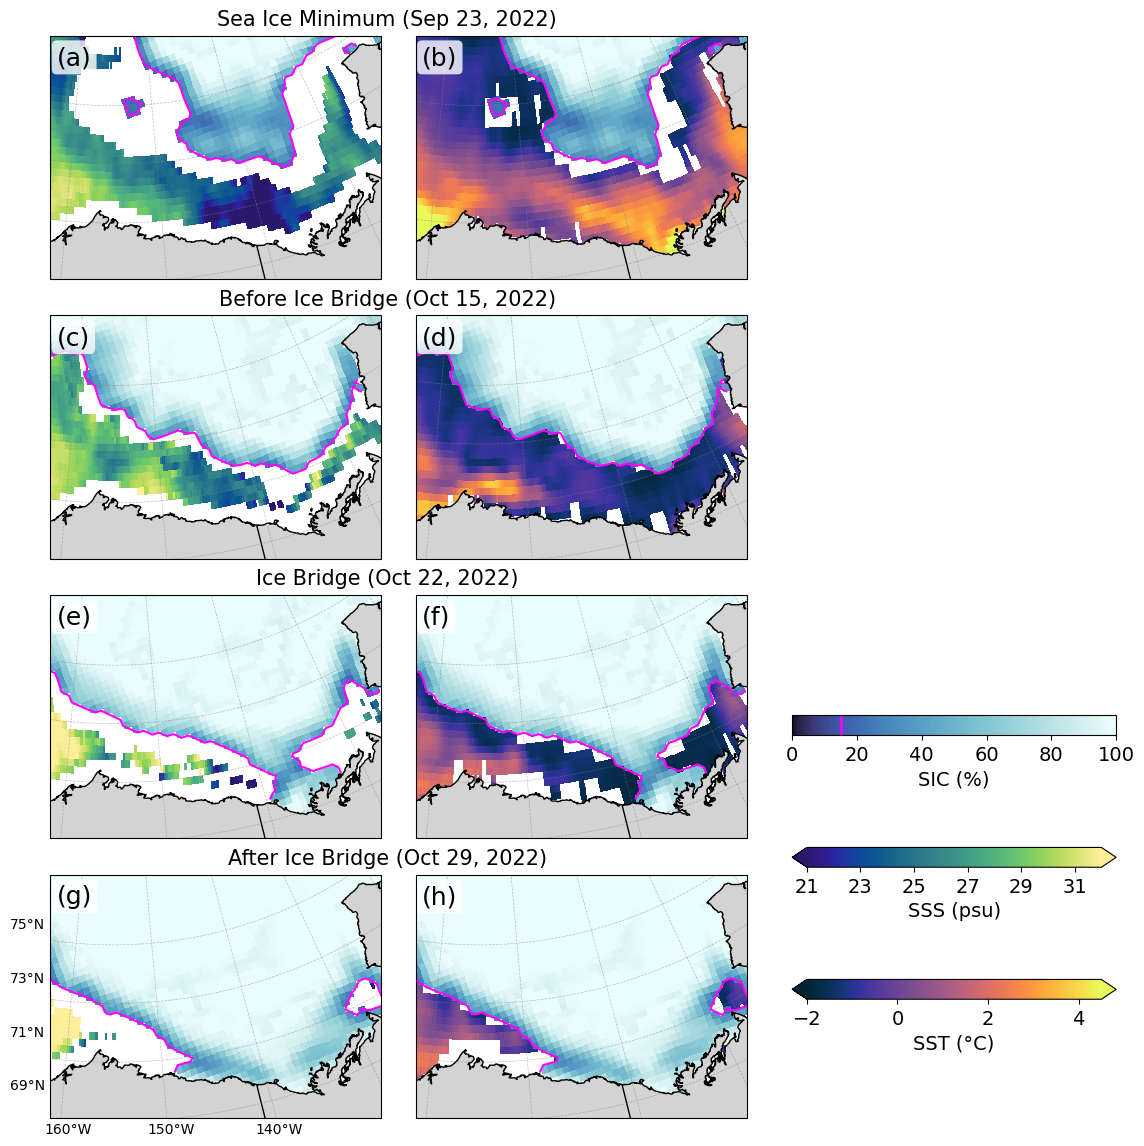

In [170]:
plt.rcParams['font.size'] = 14

# Define NSIDC stereographic projection
nsidc_proj = Proj(proj='stere', lat_0=90, lon_0=-45, lat_ts=70,
                  a=6378273, b=6356889.449, units='m')
transformer = Transformer.from_proj(nsidc_proj, "epsg:4326", always_xy=True)

# Create 4x2 plot
fig, axes = plt.subplots(4, 2, figsize=(9, 13.2),
                         subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)})
plt.subplots_adjust(wspace=0.1, hspace=0.15, right=0.9, top=0.93)
axes = axes.reshape(4, 2)

labels = list(string.ascii_lowercase)  # ['a', 'b', 'c', ...]
pcolormesh_handle = None  # for SIC colorbar

# To hold handles for SSS/SST colorbars
sss_im_list = []
sst_im_list = []

for i in range(len(sic_file_paths)):
    # Load SIC and convert
    sic_ds = xr.open_dataset(sic_file_paths[i])
    sic = sic_ds['cdr_seaice_conc'].squeeze()
    if sic.max() > 1.5:
        sic = sic / 100.0
    sic_masked = np.where(sic > 0.15, sic, np.nan)

    # Load SSS and SST
    sss = xr.open_dataset(sss_file_paths[i])['sss_smap'].squeeze()
    sst = xr.open_dataset(sst_file_paths[i])['sst'].squeeze()
    sst_ice = xr.open_dataset(sst_file_paths[i])['ice'].squeeze()

    # Get grid and lat/lon
    x = sic_ds['x'].values
    y = sic_ds['y'].values
    X, Y = np.meshgrid(x, y)
    lon, lat = transformer.transform(X, Y)

    # # Define custom row label
    # row_titles = ["Sea Ice Minimum", "Before Ice Bridge", "Ice Bridge", "After Ice Bridge"]
    # dt = pd.to_datetime(sic_ds['time'].values)
    # date_str = dt.strftime('%b %d, %Y')
    # row_title = f"{row_titles[i]} ({date_str[0]})"
    # fig.text(0.5, 0.935 - i * 0.216, row_title, ha='center', fontsize=15)

    # Define custom row labels
    row_titles = ["Sea Ice Minimum", "Before Ice Bridge", "Ice Bridge", "After Ice Bridge"]
    
    # Define title with date
    dt = pd.to_datetime(sic_ds['time'].values)
    date_str = dt.strftime('%b %d, %Y')
    row_title = f"{row_titles[i]} ({date_str[0]})"

    # Determine top y-position of the row using both subplots in the row
    row_top_y = max(axes[i, 0].get_position().y1, axes[i, 1].get_position().y1)

    # Place title a bit above the top of the row
    fig.text(0.5, row_top_y + 0.008, row_title, ha='center', fontsize=15)

    for j in range(2):  # j=0 (SSS), j=1 (SST)
        ax = axes[i, j]
        ax.set_extent([-161, -129, 69, 76], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m', facecolor='lightgray'))
        ax.add_feature(cfeature.BORDERS.with_scale('10m'))
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'))
        gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray',
                          alpha=0.5, linestyle='--', ylocs=[67, 69, 71, 73, 75])

        # Plot SSS and SST
        if j == 0:
            sss_cb = sss.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.haline,
                          vmin=21, vmax=32, add_colorbar=False, extend='both')
        else:
            sst_cb = sst.where(sst_ice.isnull()).plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.thermal,
                          vmin=-2, vmax=4.5, add_colorbar=False, extend='both')

        # Overlay SIC on top
        sic_cb = ax.pcolormesh(lon, lat, sic_masked * 100, transform=ccrs.PlateCarree(),
                               cmap=custom_ice_cmap, shading='auto', vmin=0, vmax=100)

        ax.set_title("")
        
        # Add 15% contour
        regional_mask = ((lon >= -165) & (lon <= -120) & (lat >= 66) & (lat <= 80))
        sic_region = np.where(regional_mask, sic, np.nan)
        ax.contour(lon, lat, sic_region * 100, levels=[15], colors='magenta',
                   linewidths=1.5, transform=ccrs.PlateCarree())

        # Subplot label
        ax.text(0.02, 0.96, f'({labels[i * 2 + j]})', transform=ax.transAxes,
                fontsize=18, va='top', ha='left',
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.8))

# Shared SSS colorbar under left column
cbar_ax_sss = fig.add_axes([0.95, 0.3, 0.36, 0.015])  # [left, bottom, width, height]
cb_sss = fig.colorbar(sss_cb, cax=cbar_ax_sss, orientation='horizontal', extend='both')
cb_sss.set_label('SSS (psu)')
cb_sss.set_ticks([21,23,25,27,29,31])

cbar_ax_sic = fig.add_axes([0.95, 0.4, 0.36, 0.015])  # [left, bottom, width, height]
cb_sic = fig.colorbar(sic_cb, cax=cbar_ax_sic, orientation='horizontal')
cb_sic.set_label('SIC (%)')
cb_sic.ax.vlines(15, *cb_sic.ax.get_xlim(), colors='magenta', linewidth=2)

# Shared SST colorbar under right column
cbar_ax_sst = fig.add_axes([0.95, 0.2, 0.36, 0.015])
cb_sst = fig.colorbar(sst_cb, cax=cbar_ax_sst, orientation='horizontal', extend='both')
cb_sst.set_label('SST (°C)')

# Lat/lon labels
fig.text(0.12, 0.135, '69°N', fontsize=10, ha='right', va='center')
fig.text(0.12, 0.175, '71°N', fontsize=10, ha='right', va='center')
fig.text(0.12, 0.216, '73°N', fontsize=10, ha='right', va='center')
fig.text(0.12, 0.257, '75°N', fontsize=10, ha='right', va='center')
fig.text(0.145, 0.107, '160°W', fontsize=10, ha='center', va='top')
fig.text(0.26, 0.107, '150°W', fontsize=10, ha='center', va='top')
fig.text(0.38, 0.107, '140°W', fontsize=10, ha='center', va='top')

# Show or save
# fig.savefig('your_output_path.png', dpi=300, bbox_inches='tight')
plt.show()

Map of area

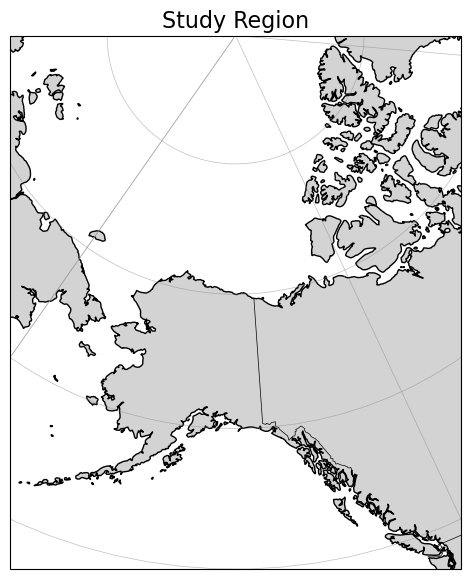

In [142]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box
import cartopy.io.shapereader as shpreader
from cartopy.geodesic import Geodesic

# Define projection: NSIDC-style polar stereographic projection
proj = ccrs.NorthPolarStereo(central_longitude=-145)

# Define bounds of your subplot maps (example: Beaufort Sea area)
# Replace these with the correct bounding box in lon/lat
min_lon, max_lon = -160, -120
min_lat, max_lat = 68, 75

# Set up figure
fig = plt.figure(figsize=(5, 6))
ax = plt.axes(projection=proj)

# Add geographic features
ax.coastlines(resolution='50m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Set extent for North America in stereographic (lat0=90)
ax.set_extent([-170, -120, 50, 90], crs=ccrs.PlateCarree())

# # Draw a red box for the mapped region
# region_box = box(min_lon, min_lat, max_lon, max_lat)
# ax.add_geometries(
#     [region_box],
#     crs=ccrs.PlateCarree(),
#     facecolor='none',
#     edgecolor='red',
#     linewidth=2
# )

# Optional: Add a grid
gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Optional: Add a label or arrow pointing to the box
# ax.text(-140, 80, 'Study Area', transform=ccrs.PlateCarree(), color='red')

plt.title("Study Region", fontsize=16)
plt.tight_layout()
plt.show()

### Calculate sea ice minimum for box

In [156]:
sic_sept_paths = [item for item in sic_file_paths_2022 if '202209' in item]

In [157]:
sic_ds = xr.open_mfdataset(sic_sept_paths)

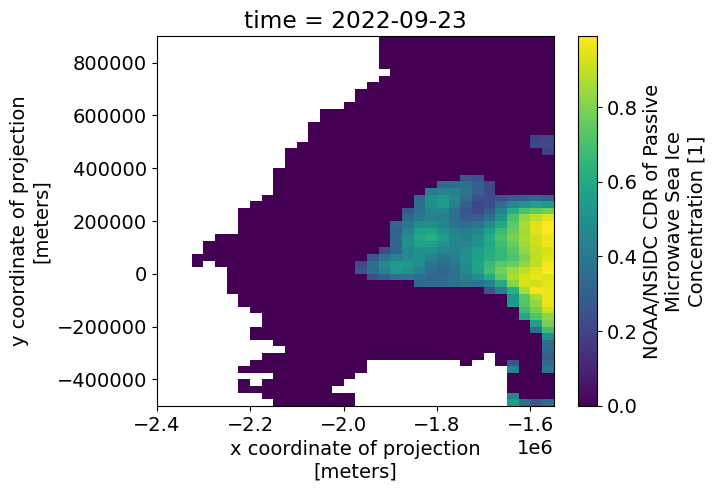

In [163]:
sic_ds.cdr_seaice_conc.sel(time='2022-09-23').sel(x=slice(-2.4e6,-1.56e6),y=slice(0.9e6,-0.5e6)).plot();

In [88]:
# open ancillary ds
meta_ds = xr.open_dataset('/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr/G02202-ancillary-psn25-v05r00.nc')

In [164]:
# isolate beaufort box
sic_beaufort = sic_ds.cdr_seaice_conc.sel(x=slice(-2.4e6,-1.56e6),y=slice(0.9e6,-0.5e6))
meta_beaufort = meta_ds.sel(x=slice(-2.4e6,-1.56e6),y=slice(0.9e6,-0.5e6))

In [165]:
# calculate area of grid cells
earth_radius = 6371.0  # km
grid_res_km = 25 # NSIDC CDR is 25 km resolution
lat = meta_beaufort.latitude

# calculate approximate area: area = dx * dy * cos(lat)
# where dx = dy = 25 km, and cos(lat) accounts for grid convergence
area_approx = (grid_res_km ** 2) * np.cos(np.deg2rad(lat))
area_da = xr.DataArray(area_approx, dims=lat.dims, coords=lat.coords, name='grid_cell_area')

# Create SIC mask where concentration > 15%
sic_mask = sic_beaufort*100 > 15

# Calculate sea ice extent: sum of grid cell areas where SIC > 15%
extent_ts = (sic_mask * area_da).sum(dim=('y', 'x'))
extent_ts.name = 'sea_ice_extent_km2'

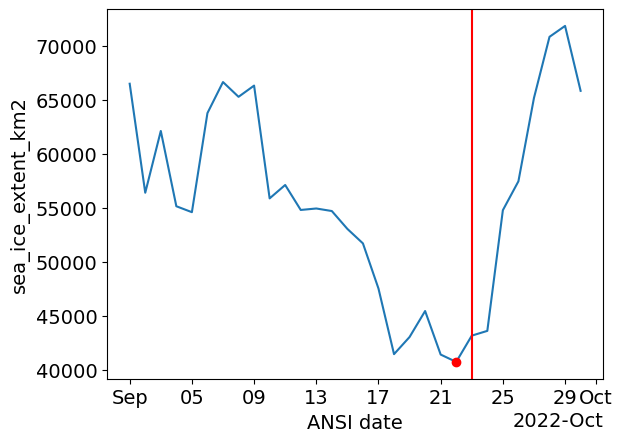

In [167]:
# Plot or inspect
extent_ts.plot();
extent_ts.where(extent_ts==extent_ts.min().values).plot(marker='o',color='r');
plt.axvline(x=np.datetime64('2022-09-23'),color='r');